In [20]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:


# INPUTS

C0 = 100.0
order = 1
A_factor = 4.83e13
Ea = 100000
R_gas = 8.314
temperatures_C = [25, 40, 60]
t_max = 800
n_points = 400
shelf_life_limit = 0.10




In [22]:
# ARRHENIUS EQUATION
def arrhenius_k(A_factor, Ea, T_kelvin):
    # k = A * exp( -Ea / (R * T) )
      return A_factor * np.exp(-Ea / (R_gas * T_kelvin))

In [23]:
# INTEGRATED RATE LAW
def concentration_profile(C0, k, order, t):
    # -dC/dt = k * C^order,

    if order == 0:
        C = C0 - k * t
        C = np.clip(C, 0, None)
    elif order == 1:
        C = C0 * np.exp(-k * t)
    elif order == 2:
        C = C0 / (1 + k * C0 * t)
    else:
        raise ValueError("order must be 0, 1, or 2")
    return C

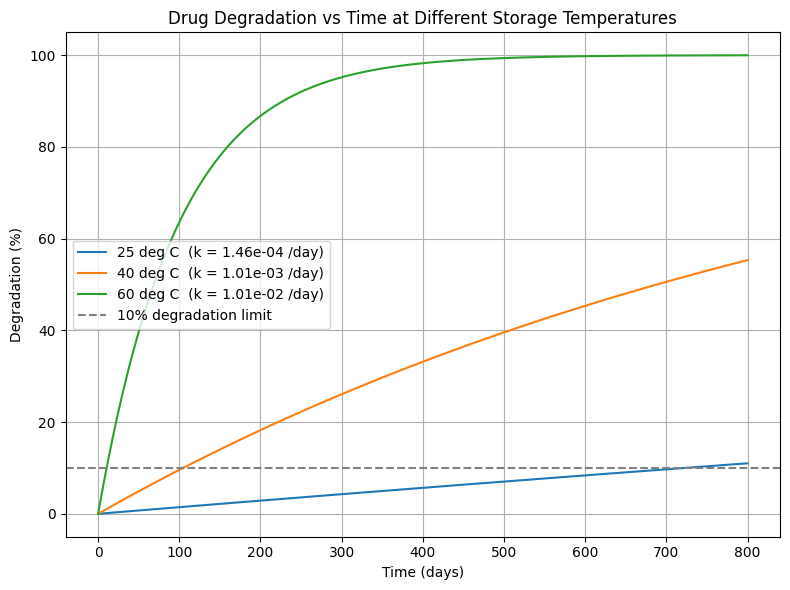

In [24]:
# RUNNING THE SIMULATION FOR EACH TEMPERATURE

t = np.linspace(0, t_max, n_points)

plt.figure(figsize=(8, 6))

results_summary = []

for T_C in temperatures_C:
    T_K = T_C + 273.15
    k = arrhenius_k(A_factor, Ea, T_K)
    C = concentration_profile(C0, k, order, t)
    fraction_degraded = 1 - (C / C0)

    plt.plot(t, fraction_degraded * 100,
             label=f"{T_C} deg C  (k = {k:.2e} /day)")

  # finding the first day where degradation crosses the shelf-life limit
    over_limit = fraction_degraded >= shelf_life_limit
    if np.any(over_limit):
        shelf_life_days = t[np.argmax(over_limit)]
    else:
        shelf_life_days = None

    results_summary.append((T_C, k, shelf_life_days))

plt.axhline(shelf_life_limit * 100, color="gray", linestyle="--",
            label=f"{int(shelf_life_limit*100)}% degradation limit")
plt.xlabel("Time (days)")
plt.ylabel("Degradation (%)")
plt.title("Drug Degradation vs Time at Different Storage Temperatures")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("degradation_vs_time.png", dpi=150)
plt.show()
plt.close()




In [25]:
# PRINTING A SUMMARY TABLE

print("\nSHELF-LIFE SUMMARY (time to reach {}% degradation)".format(
    int(shelf_life_limit * 100)))
print(f"{'Temp (C)':>10} {'k (1/day)':>15} {'Shelf life (days)':>20}")
for T_C, k, shelf_life_days in results_summary:
    life_str = f"{shelf_life_days:.1f}" if shelf_life_days is not None else "not reached"
    print(f"{T_C:>10} {k:>15.3e} {life_str:>20}")


SHELF-LIFE SUMMARY (time to reach 10% degradation)
  Temp (C)       k (1/day)    Shelf life (days)
        25       1.458e-04                723.8
        40       1.007e-03                106.3
        60       1.010e-02                 12.0


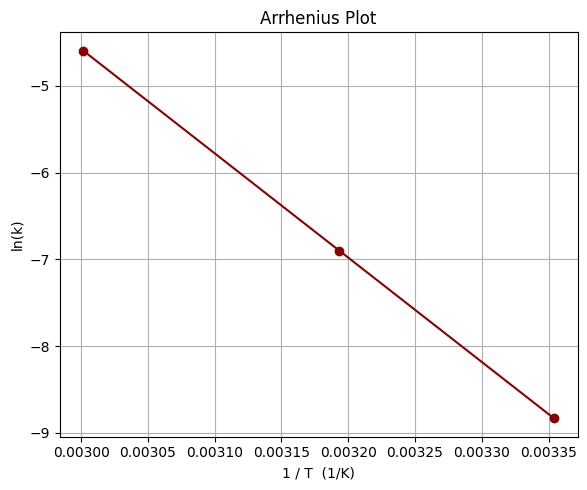


Saved plots: degradation_vs_time.png and arrhenius_plot.png


In [26]:
# ARRHENIUS PLOT (ln k vs 1/T)

T_kelvin_arr = np.array([T_C + 273.15 for T_C in temperatures_C])
k_arr = np.array([arrhenius_k(A_factor, Ea, T) for T in T_kelvin_arr])

plt.figure(figsize=(6, 5))
plt.plot(1 / T_kelvin_arr, np.log(k_arr), "o-", color="darkred")
plt.xlabel("1 / T  (1/K)")
plt.ylabel("ln(k)")
plt.title("Arrhenius Plot")
plt.grid(True)
plt.tight_layout()
plt.savefig("arrhenius_plot.png", dpi=150)
plt.show()
plt.close()

print("\nSaved plots: degradation_vs_time.png and arrhenius_plot.png")